In [3]:
%load_ext autoreload
%autoreload 2   


from freyrelab.nets.powerlaw import Ck, Pk

G = nx.erdos_renyi_graph(100, 0.1)
G = rn.RegNet(G)

In [110]:
import inspect
import numpy as np
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt

from netective import properties
from netective.utils import compute_moments

In [172]:
parent_class = properties._Property

def get_child_classes(parent_class):
    child_classes = []
    for name, obj in inspect.getmembers(properties):
        if inspect.isclass(obj) and issubclass(obj, parent_class) and obj != parent_class:
            child_classes.append(obj)
    return child_classes

child_classes = get_child_classes(parent_class)


def get_instances(G, child_classes):
    instances = {x.__name__ : x(G) for x in child_classes}
    return instances

def normalize_props(instances, G, norm='network'):
    norm_scalar_values = {}
    norm_dist_values = {}
    for name, x in instances.items():
        dict_ = norm_scalar_values if x._return_type == 'scalar' else norm_dist_values
        try:
            if norm == 'network':
                dict_[x.__name__] = x.norm_network()
            elif norm == 'biol':
                dict_[x.__name__] = x.norm_biol()
        except (NotImplementedError, properties.NormalizationError):
            dict_[x.__name__] = np.nan

    norm_dist_values = {k: v for k, v in norm_dist_values.items() if not np.isnan(v).all()}
    norm_scalar_values = {k: v for k, v in norm_scalar_values.items() if not np.isnan(v)}

    return norm_scalar_values, norm_dist_values

def plot_distributions(dist_values):

    # Determine the grid shape based on the number of items
    num_items = len(dist_values)
    grid_shape = (int(np.sqrt(num_items)), int(np.ceil(np.sqrt(num_items))))

    # Create the figure and subplots
    fig, axs = plt.subplots(nrows=grid_shape[0], ncols=grid_shape[1], figsize=(3*grid_shape[0], 1.5*grid_shape[1]))

    # Flatten the axes array if it's more than 1D
    if num_items > 1:
        axs = axs.flatten()

    # Iterate over the dictionary items and create the subplots
    for i, (title, data) in enumerate(dist_values.items()):
        ax = axs[i] if num_items > 1 else axs  # Use a single axis if there's only one item
        sns.kdeplot(data, ax=ax, fill=True, color="#384265")
        ax.set_title(title)

    # Remove any extra empty subplots
    if num_items < axs.size:
        for j in range(num_items, axs.size):
            fig.delaxes(axs[j])

    # Adjust spacing between subplots
    fig.tight_layout()

    return fig, axs

def plot_scalars(data_dict):
    # Extract keys (strings) and values (floats) from the dictionary
    labels = list(data_dict.keys())
    values = list(data_dict.values())

    with sns.axes_style("darkgrid"):
        # Create the figure and axes
        fig, axs = plt.subplots(figsize=(2, 0.3*len(labels)))

        # Create a horizontal bar plot using seaborn
        sns.barplot(x=values, y=labels, ax=axs, color="#384265")

        # Add annotations to the bars
        for i, value in enumerate(values):
            if isinstance(value, float):
                if value.is_integer():
                    value = int(value)
                else:
                    value = round(value, 2) if value >= .01 else value
            plt.text(value, i, str(value) if value >= .01 else f"{value:.2E}", va='center')

        # Customize the plot
        axs.set_xlabel('Values')
        axs.set_ylabel('')

    return fig, axs


def main(G, norm='network'):
    instances = get_instances(G, child_classes)
    scalar_values = {name : x.compute() for name, x in instances.items() if x._return_type == 'scalar'}
    dist_values = {name : x.compute() for name, x in instances.items() if x._return_type == 'distribution'}

    if norm:
        scalar_values, dist_values = normalize_props(instances, G)
        
    fig, axs = plot_distributions(dist_values)
    fig, axs = plot_scalars(scalar_values)


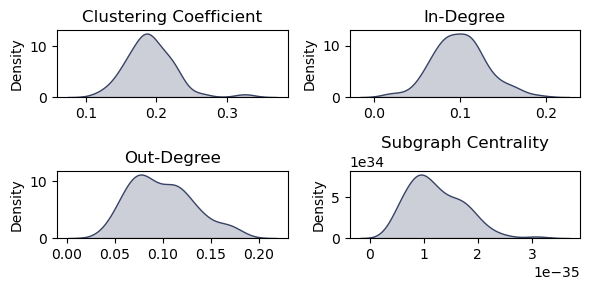

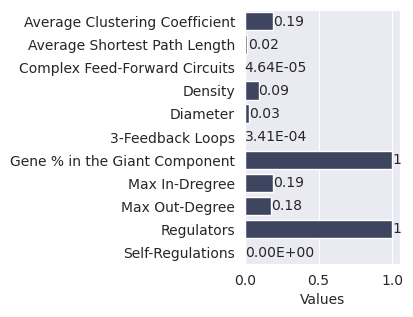

In [173]:
G = nx.erdos_renyi_graph(100, 0.1, directed=True)
G = rn.RegNet(G)
main(G, norm='network')

In [162]:
regulators = [node for node in G.nodes if G.in_degree(node) > 0]
len(regulators)

100

## Test with network

In [182]:
with open(r"C:\Users\jmere\OneDrive\Escritorio\A_Ecoli K12 93 TFs.txt", "r") as file_obj:
    G = nx.read_edgelist(file_obj, delimiter=" ", create_using=nx.DiGraph, data=False)
    G = rn.RegNet(G)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\jmere\\OneDrive\\Escritorio\\A_Ecoli K12 93 TFs.txt'

In [175]:
norm = 'network'
instances = get_instances(G, child_classes)
scalar_values = {name : x.compute() for name, x in instances.items() if x._return_type == 'scalar'}
dist_values = {name : x.compute() for name, x in instances.items() if x._return_type == 'distribution'}

if norm:
    scalar_values, dist_values = normalize_props(instances, G)

c:\Users\jmere\.conda\envs\pyfl38\lib\site-packages\networkx\algorithms\centrality\subgraph_alg.py:182: RuntimeWarning: overflow encountered in exp
  expw = np.exp(w)


In [176]:
dist_values['Subgraph Centrality']

array([0., 0., 0., ..., 0., 0., 0.])

In [177]:
scalar_values

{'Average Clustering Coefficient': 0.10962920542327349,
 'Average Shortest Path Length': 0.0014353357812143996,
 'Complex Feed-Forward Circuits': 1.582016552047141e-08,
 'Density': 0.0013341551092992277,
 'Diameter': 0.003216911764705882,
 '3-Feedback Loops': 3.882249207477647e-10,
 'Gene % in the Giant Component': 1.0,
 'Max In-Dregree': 0.006430868167202572,
 'Max Out-Degree': 0.23059255856683508,
 'Regulators': 0.042259990813045475,
 'Self-Regulations': 0.015617822691777675}

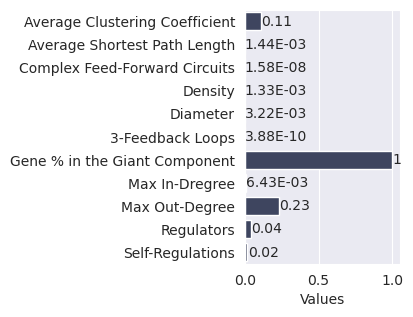

In [178]:
fig, axs = plot_scalars(scalar_values)

In [21]:
# mean, variance, skewness, kurt = 
[compute_moments(array) for array in norm_values.values() if isinstance(array, np.ndarray)]

[(0.08350094246998271,
  0.00238570807925752,
  0.6872949033868105,
  0.6725004777307237),
 (0.09860000000000001,
  0.000872767676767677,
  0.6808277065558661,
  0.9418780091052117),
 (0.09860000000000001,
  0.000872767676767677,
  0.6808277065558661,
  0.9418780091052117),
 (1.9290000629410147e-39,
  1.8156499811586458e-78,
  1.8544008876699085,
  5.039150566948628)]

In [180]:
# mean, variance, skewness, kurt = 
foo = [compute_moments(array) for array in norm_values.values() if isinstance(array, np.ndarray)]
foo

[(0.08350094246998271,
  0.00238570807925752,
  0.6872949033868105,
  0.6725004777307237),
 (0.09860000000000001,
  0.000872767676767677,
  0.6808277065558661,
  0.9418780091052117),
 (0.09860000000000001,
  0.000872767676767677,
  0.6808277065558661,
  0.9418780091052117),
 (1.9290000629410147e-39,
  1.8156499811586458e-78,
  1.8544008876699085,
  5.039150566948628)]

In [181]:
np.fromiter(foo, dtype=float)

ValueError: setting an array element with a sequence.

In [183]:
G = nx.erdos_renyi_graph(100, 0.1, directed=True)

with open(r"C:\Users\jmere\OneDrive\Escritorio\ER.txt", 'w') as out:
    for edge in G.edges:
        out.write(f"{edge[0]} {edge[1]}\n")

In [184]:
from scipy.stats import pearsonr

foo = [, 2.00864784e+01, , 2.17677652e+00, -1.69545146e-01, , 9.52517107e-01, , 1.02407893e+01, , 1.35129324e+00, , 4.97479849e-01, , 2.21999571e+00, , 1.95320105e-01, , 1.37413935e-03, -1.56076108e-01, , 7.91994788e-01, , 9.99000000e+00, , 8.51505051e+00, , 2.42808923e-01, , 2.47568537e-01, , 9.72361164e-02, , 1.01901624e-03, -9.93401480e-02, -6.19158863e-01, , 9.99000000e+00, , 1.15655556e+01, , 1.51082073e-01, -2.82099930e-01, , 1.09460214e+00, , 4.58564331e+00, , 2.69915712e+00, , 6.57429725e+00, , 4.48324698e+06, , 4.27989863e+12, , 4.05720218e-01, -7.15329831e-01]

spam = [ 2.00864784e+01  2.17677652e+00 -1.69545146e-01  9.52517107e-01
  1.02407893e+01  1.35129324e+00  4.97479849e-01  2.21999571e+00
  1.95320105e-01  1.37413935e-03 -1.56076108e-01  7.91994788e-01
  9.99000000e+00  8.51505051e+00  2.42808923e-01  2.47568537e-01
  9.72361164e-02  1.01901624e-03 -9.93401480e-02 -6.19158863e-01
  9.99000000e+00  1.15655556e+01  1.51082073e-01 -2.82099930e-01
  1.09460214e+00  4.58564331e+00  2.69915712e+00  6.57429725e+00
  4.48324698e+06  4.27989863e+12  4.05720218e-01 -7.15329831e-01]

pearsonr(foo, spam)

SyntaxError: invalid syntax (2614441092.py, line 3)

In [187]:
"""[ 2.00864784e+01  2.17677652e+00 -1.69545146e-01  9.52517107e-01
  1.02407893e+01  1.35129324e+00  4.97479849e-01  2.21999571e+00
  1.95320105e-01  1.37413935e-03 -1.56076108e-01  7.91994788e-01
  9.99000000e+00  8.51505051e+00  2.42808923e-01  2.47568537e-01
  9.72361164e-02  1.01901624e-03 -9.93401480e-02 -6.19158863e-01
  9.99000000e+00  1.15655556e+01  1.51082073e-01 -2.82099930e-01
  1.09460214e+00  4.58564331e+00  2.69915712e+00  6.57429725e+00
  4.48324698e+06  4.27989863e+12  4.05720218e-01 -7.15329831e-01]""".replace(' ', ', ').replace('\n', '')

'[, 2.00864784e+01, , 2.17677652e+00, -1.69545146e-01, , 9.52517107e-01, , 1.02407893e+01, , 1.35129324e+00, , 4.97479849e-01, , 2.21999571e+00, , 1.95320105e-01, , 1.37413935e-03, -1.56076108e-01, , 7.91994788e-01, , 9.99000000e+00, , 8.51505051e+00, , 2.42808923e-01, , 2.47568537e-01, , 9.72361164e-02, , 1.01901624e-03, -9.93401480e-02, -6.19158863e-01, , 9.99000000e+00, , 1.15655556e+01, , 1.51082073e-01, -2.82099930e-01, , 1.09460214e+00, , 4.58564331e+00, , 2.69915712e+00, , 6.57429725e+00, , 4.48324698e+06, , 4.27989863e+12, , 4.05720218e-01, -7.15329831e-01]'